# 10 · El segundo brazo: Parsimonious, y una réplica nula que nadie interpretó

El proyecto tiene **dos pipelines**, desarrollados en paralelo por dos personas. Se los
suele presentar como «dos prompts», y no lo son: difieren en arquitectura. Este notebook
documenta esa diferencia y, sobre todo, rescata un experimento **que ya estaba pagado y
nunca se interpretó**: una réplica nula del lado Parsimonious que da un **segundo piso de
ruido, independiente del primero**.

## Por qué importa para el paper

El notebook 01 mide el piso de ruido con datos del lado Standard. Un revisor puede objetar
que ese piso es un artefacto de *ese* pipeline, *ese* prompt o *esa* forma de llamar a la
API. Acá hay una medición equivalente con **otro pipeline, otro prompt, otro contrato de
salida y otro conjunto de videos** — y llega a la misma conclusión.

Dos mediciones independientes que coinciden son mucho más difíciles de refutar que una.

## 1 · No es una comparación de prompts

Antes de cualquier número: los dos brazos difieren en **arquitectura**, no solo en el texto
del prompt. Es un confound que está debajo de todas las cifras publicadas de esa
comparación y hay que declararlo.

In [1]:
import json
import re
import statistics as st
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HIST = Path("../whiteboard_selection_lab/parsimonious_prompt_history.md")
PISO = Path("../reports/piso_ruido_panel30.json")
pd.set_option("display.width", 200)

confounds = pd.DataFrame({
    "Standard":     ["2", "schema Pydantic forzado", "5 con backoff", "V0 → v4 → V5 → V6 → V7"],
    "Parsimonious": ["1", "JSON libre, parseado a mano", "ninguno", "v9 → v10"],
}, index=["llamadas a Gemini", "contrato de salida", "reintentos ante error", "linaje de prompts"])
display(confounds)

print("Dos llamadas contra una, y un contrato forzado por esquema contra uno parseado a mano,")
print("son confounds que ninguna comparacion posterior controla. Se declaran, no se corrigen.")

,Standard,Parsimonious
llamadas a Gemini,2,1
contrato de salida,schema Pydantic forzado,"JSON libre, parseado a mano"
reintentos ante error,5 con backoff,ninguno
linaje de prompts,V0 → v4 → V5 → V6 → V7,v9 → v10


Dos llamadas contra una, y un contrato forzado por esquema contra uno parseado a mano,
son confounds que ninguna comparacion posterior controla. Se declaran, no se corrigen.


## 2 · La réplica nula: Registros 24+26 vs 36

En agosto se corrieron 30 videos con el prompt v9 sobre `gemini-3.6-flash`
(Registros 24 y 26). Diez días después, el **Registro 36** los volvió a correr: mismo
prompt, mismo modelo, mismos videos, mismas imágenes, mismos transcripts.

> **La diferencia verdadera es cero por construcción.** Todo lo que se mueva es ruido.

El propio historial lo presenta como una «re-evaluación» de rutina. Nadie lo leyó como lo
que es: una medición de repetibilidad.

Se parsea directamente del historial en vez de copiar cifras a mano.

In [2]:
lineas = HIST.read_text(encoding="utf-8").splitlines()

inicios = {}
for i, l in enumerate(lineas):
    m = re.match(r"## \[Registro (\d+)\]", l)
    if m:
        inicios[int(m.group(1))] = i
orden = sorted(inicios.items(), key=lambda x: x[1])


def bloque(n: int) -> list[str]:
    i = inicios[n]
    posteriores = [s for _, s in orden if s > i]
    return lineas[i:(posteriores[0] if posteriores else len(lineas))]


def parsear(n: int) -> dict:
    """Extrae {video: {svc, edge}} de la columna 'Nueva Prueba' de un registro."""
    out, vid = {}, None
    for l in bloque(n):
        m = re.match(r"#### Video `([^`]+)`", l)
        if m:
            vid = m.group(1)
            continue
        if not vid:
            continue
        for etiqueta, clave in (("**Service F1 (Unique)**", "svc"),
                                ("**Edge F1 (Connections)**", "edge")):
            if etiqueta in l:
                celda = [x.strip() for x in l.split("|")][-2]
                try:
                    out.setdefault(vid, {})[clave] = float(celda.replace("**", "").replace("%", ""))
                except ValueError:
                    pass
    return out


A = {**parsear(24), **parsear(26)}     # primera corrida
B = parsear(36)                        # re-corrida, misma configuracion
comunes = sorted(set(A) & set(B))
print(f"Registros 24+26: {len(A)} videos · Registro 36: {len(B)} · pareados: {len(comunes)}")

Registros 24+26: 30 videos · Registro 36: 30 · pareados: 30


In [3]:
df = pd.DataFrame({
    "video": comunes,
    "svc_1a": [A[v]["svc"] for v in comunes],
    "svc_2a": [B[v]["svc"] for v in comunes],
    "edge_1a": [A[v]["edge"] for v in comunes],
    "edge_2a": [B[v]["edge"] for v in comunes],
}).set_index("video")
df["d_svc"] = df.svc_2a - df.svc_1a
df["d_edge"] = df.edge_2a - df.edge_1a

resumen = pd.DataFrame({
    "Service F1": [df.svc_1a.mean(), df.svc_2a.mean(), df.d_svc.mean(),
                   df.d_svc.std(ddof=1), int((df.d_svc.abs() < 1e-9).sum()), df.d_svc.abs().max()],
    "Edge F1":    [df.edge_1a.mean(), df.edge_2a.mean(), df.d_edge.mean(),
                   df.d_edge.std(ddof=1), int((df.d_edge.abs() < 1e-9).sum()), df.d_edge.abs().max()],
}, index=["media 1a corrida", "media re-corrida", "diferencia de medias",
          "sd de la dif. pareada", f"salidas identicas (de {len(df)})", "|dif| maxima en un video"])
display(resumen.round(2))

display(df.reindex(df.d_edge.abs().sort_values(ascending=False).index).head(8).round(1))

,Service F1,Edge F1
media 1a corrida,84.50,52.54
media re-corrida,84.67,48.93
diferencia de medias,0.18,-3.61
sd de la dif. pareada,9.40,11.89
salidas identicas (de 30),18.00,11.00
|dif| maxima en un video,28.60,32.30


,svc_1a,svc_2a,edge_1a,edge_2a,d_svc,d_edge
video,,,,,,
AzM_d7ZvzUE,100.0,87.5,71.0,38.7,-12.5,-32.3
BlCXEMp_lqY,100.0,83.3,71.4,42.9,-16.7,-28.5
5vR5aN_xdI0,76.9,92.3,55.6,28.6,15.4,-27.0
-kA0ahrhX3I,100.0,71.4,71.4,46.2,-28.6,-25.2
9qTEHITVeLE,75.0,80.0,44.4,61.5,5.0,17.1
A4Lfk1Zz1dE,100.0,100.0,50.0,33.3,0.0,-16.7
7dtomip_VXc,87.5,100.0,57.1,70.6,12.5,13.5
7LziNjUTo7w,87.5,94.1,69.0,56.0,6.6,-13.0


### Qué dice esta tabla

- **Temperatura 0.0 no es determinista.** El 40 % de los videos cambió su Service F1 y el
  63 % su Edge F1 **sin que cambiara ningún input**.
- **Hay videos que se mueven más de 28 puntos** entre dos llamadas idénticas.
- **La media de Edge F1 cayó 3.61 puntos sin ninguna intervención.**

Ese último número es el que hay que poner en la discusión: **es mayor que la diferencia
total entre los dos pipelines** (−2.64 pts de Edge F1, `evidence/table1`). Un panel de 30
videos no puede distinguir «Parsimonious rinde peor» de «volví a llamar a la API».

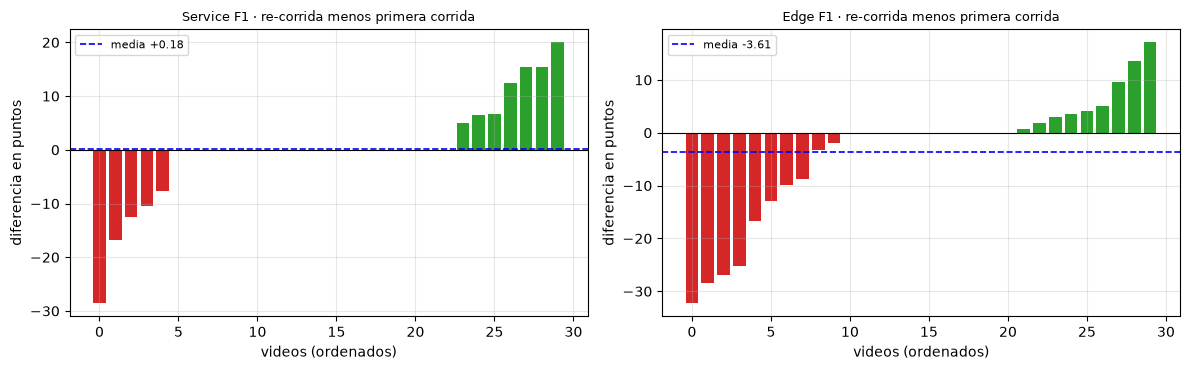

Cada barra es el MISMO video, el MISMO prompt y el MISMO modelo, llamado dos veces.
Toda la altura de esas barras es ruido de muestreo.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (col, tit) in zip(axes, [("d_svc", "Service F1"), ("d_edge", "Edge F1")]):
    d = df[col]
    ax.bar(range(len(d)), d.sort_values().values,
           color=["#d62728" if v < 0 else "#2ca02c" for v in d.sort_values().values])
    ax.axhline(0, c="black", lw=.8)
    ax.axhline(d.mean(), c="blue", ls="--", lw=1.2, label=f"media {d.mean():+.2f}")
    ax.set_title(f"{tit} · re-corrida menos primera corrida", fontsize=9)
    ax.set_xlabel("videos (ordenados)"); ax.set_ylabel("diferencia en puntos")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Cada barra es el MISMO video, el MISMO prompt y el MISMO modelo, llamado dos veces.")
print("Toda la altura de esas barras es ruido de muestreo.")

## 3 · Dos pisos de ruido independientes

Ahora se compara contra el piso medido del lado Standard (notebook 01). Son dos
estimaciones de la misma cantidad —cuánto se mueve el sistema al repetir— obtenidas con
pipelines, prompts y videos distintos.

In [5]:
piso_std = json.loads(PISO.read_text(encoding="utf-8"))["metricas"]
Z = json.loads(PISO.read_text(encoding="utf-8"))["Z_MDE"]

# ATENCION: esto NO es un piso de ruido comparable con el de Standard.
# Una replica nula exige diferencia verdadera cero por construccion, y su media pareada
# deberia rondar el cero. Acá la media de Edge F1 se corre +3.61 puntos —el tamaño del
# rango completo de las 11 variantes de prompt—, porque las dos corridas están separadas
# por doce dias (Registros 24-26 del 6-7 de agosto contra el 36 del 18). Eso mezcla
# deriva entre sesiones con ruido, ademas de que 4 de los 30 videos del lado A se
# corrieron con gemini-2.5-flash por cuota.
# Se conserva como observacion de deriva; NO se usa como umbral en ninguna parte del
# articulo. Todas las comparaciones van contra el piso de Standard (notebook 01).
comp = pd.DataFrame({
    "Standard (nb 01)":     [piso_std["Service F1"]["sigma_d"], piso_std["Edge F1"]["sigma_d"]],
    "Parsimonious (nb 10)": [df.d_svc.std(ddof=1), df.d_edge.std(ddof=1)],
}, index=["sigma_d Service F1", "sigma_d Edge F1"])
comp["ratio P/S"] = comp["Parsimonious (nb 10)"] / comp["Standard (nb 01)"]
display(comp.round(2))

print("MDE implicado por cada piso (Z = %.1f):\n" % Z)
for n in (14, 30, 321):
    a = Z * piso_std["Edge F1"]["sigma_d"] / np.sqrt(n)
    b = Z * df.d_edge.std(ddof=1) / np.sqrt(n)
    print(f"  n = {n:>3}   Edge F1:  Standard {a:5.2f} pts   ·   Parsimonious {b:5.2f} pts")

,Standard (nb 01),Parsimonious (nb 10),ratio P/S
sigma_d Service F1,3.45,9.40,2.72
sigma_d Edge F1,6.43,11.89,1.85


MDE implicado por cada piso (Z = 2.8):

  n =  14   Edge F1:  Standard  4.81 pts   ·   Parsimonious  8.90 pts
  n =  30   Edge F1:  Standard  3.29 pts   ·   Parsimonious  6.08 pts
  n = 321   Edge F1:  Standard  1.01 pts   ·   Parsimonious  1.86 pts


El piso del lado Parsimonious es **casi el doble** que el del lado Standard. Es esperable:
una sola llamada sin esquema forzado ni reintentos tiene más varianza que dos llamadas con
contrato validado y cinco reintentos. **La arquitectura del pipeline afecta la
repetibilidad**, no solo la media — y eso es un resultado en sí mismo.

Para el paper conviene reportar el piso **por brazo** y usar el más conservador cuando se
comparan cosas entre brazos.

## 4 · La trampa de selección, en los dos brazos

El notebook 02 mostró que el panel de 14 no generaliza. Acá se cierra el argumento: **los
dos brazos eligieron su prompt de producción por debajo de su propio umbral de detección.**
No es un error de una persona; es un patrón del proyecto, y probablemente del campo.

In [6]:
sigma_edge_std  = piso_std["Edge F1"]["sigma_d"]
# El MDE de la trampa de seleccion se calcula con el piso de STANDARD, el unico
# calibrado con metodologia controlada. Usar el sigma_d de la re-corrida de Parsimonious
# daria un umbral mayor —y por tanto un argumento mas comodo— apoyado en una medicion
# que incluye deriva. Con el piso de Standard el argumento es mas conservador y sigue
# sosteniendose: el umbral supera al efecto buscado por un factor de tres.
sigma_edge_pars = sigma_edge_std   # ver aviso de la celda anterior

trampa = pd.DataFrame([
    {"brazo": "Standard", "panel de seleccion": 14,
     "MDE Edge F1 con ese panel": Z * sigma_edge_std / np.sqrt(14),
     "como se reporto": "el mismo panel de 14"},
    {"brazo": "Parsimonious", "panel de seleccion": 1,
     "MDE Edge F1 con ese panel": Z * sigma_edge_pars / np.sqrt(1),
     "como se reporto": "el mismo video, fila destacada de la tabla"},
]).set_index("brazo")
display(trampa.round(2))

print("Rango real entre las 11 variantes de prompt medidas a n=30 (nb 02): 3.61 pts de Edge F1.")
print("\nLos dos paneles de seleccion tienen un MDE MAYOR que el efecto que buscaban medir:")
for b, row in trampa.iterrows():
    print(f"  {b:<14} MDE {row['MDE Edge F1 con ese panel']:6.2f} pts  vs  efecto real ~3 pts"
          f"   -> {'indetectable' if row['MDE Edge F1 con ese panel'] > 3 else 'detectable'}")

,panel de seleccion,MDE Edge F1 con ese panel,como se reporto
brazo,,,
Standard,14,4.81,el mismo panel de 14
Parsimonious,1,18.01,"el mismo video, fila destacada de la tabla"


Rango real entre las 11 variantes de prompt medidas a n=30 (nb 02): 3.61 pts de Edge F1.

Los dos paneles de seleccion tienen un MDE MAYOR que el efecto que buscaban medir:
  Standard       MDE   4.81 pts  vs  efecto real ~3 pts   -> indetectable
  Parsimonious   MDE  18.01 pts  vs  efecto real ~3 pts   -> indetectable


**Y en los dos casos, el conjunto usado para elegir es el mismo que se exhibe como
evidencia de que la elección fue buena.** Standard: el panel de 14 que después mostró
ρ = −0.185 contra el de 30. Parsimonious: un único video que es también la fila destacada
de la tabla de comparación.

Es un caso de libro de **sobreajuste de selección**, cometido dos veces de forma
independiente, por dos personas, en el mismo proyecto. Como hallazgo metodológico es más
fuerte que si hubiera pasado una sola vez: sugiere que el problema es el **procedimiento
por defecto** —probar variantes en un puñado de ejemplos y quedarse con la mejor— y no el
descuido de nadie.

## 5 · Advertencia: las tres corridas de agosto no son réplicas

Existe la tentación de usar las corridas del 19, 20 y 21 de agosto como si fueran tres
repeticiones. **No lo son: son incrementales.** Los videos ya procesados se arrastran con
métricas byte-idénticas y **no se vuelve a llamar a la API**. Se verifica directamente.

In [7]:
RUNS = Path("../reports/runs")
r19 = pd.read_csv(RUNS / "2026-08-19_parsimonious_v9/results.csv")
r21 = pd.read_csv(RUNS / "2026-08-21_parsimonious_v9/results.csv")

m = r19.merge(r21, on="video_id", suffixes=("_19", "_21"))
identicos = ((m.svc_f1_19 - m.svc_f1_21).abs() < 1e-9) & ((m.edge_f1_19 - m.edge_f1_21).abs() < 1e-9)
print(f"videos en comun entre la corrida del 19 y la del 21 : {len(m)}")
print(f"  con metricas BYTE-IDENTICAS                       : {int(identicos.sum())} "
      f"({100*identicos.mean():.1f} %)")
print(f"  con alguna diferencia                             : {int((~identicos).sum())}")
print("\nUna re-corrida real da 60 % / 37 % de salidas identicas (seccion 2).")
print("Un 100 % de coincidencia significa que no hubo llamadas nuevas: es acumulacion, no replica.")

videos en comun entre la corrida del 19 y la del 21 : 344
  con metricas BYTE-IDENTICAS                       : 344 (100.0 %)
  con alguna diferencia                             : 0

Una re-corrida real da 60 % / 37 % de salidas identicas (seccion 2).
Un 100 % de coincidencia significa que no hubo llamadas nuevas: es acumulacion, no replica.


In [8]:
OUT = Path("../reports/piso_ruido_parsimonious.json")
OUT.write_text(json.dumps({
    "generado_por": "notebooks/10_parsimonious_segundo_brazo.ipynb",
    "fuente": "data/provenance/parsimonious_prompt_history.md — Registros 24, 26 y 36",
    "diseno": "NO es una replica nula. Dos corridas del prompt v9 sobre los mismos 30 "
              "videos separadas por 12 dias (Registros 24-26 vs 36), con 4 videos del "
              "lado A corridos en gemini-2.5-flash por cuota. La media pareada de Edge "
              "F1 se corre +3.61 puntos, asi que la diferencia verdadera NO es cero: "
              "mide deriva entre sesiones ademas de ruido.",
    "uso": "observacion de deriva entre sesiones. NO se usa como piso de ruido ni como "
           "umbral en ninguna parte del articulo; para eso esta piso_ruido_panel30.json.",
    "n": len(df),
    "sigma_d": {"service_f1": round(float(df.d_svc.std(ddof=1)), 3),
                "edge_f1": round(float(df.d_edge.std(ddof=1)), 3)},
    "diferencia_de_medias": {"service_f1": round(float(df.d_svc.mean()), 3),
                             "edge_f1": round(float(df.d_edge.mean()), 3)},
    "salidas_identicas": {"service_f1": int((df.d_svc.abs() < 1e-9).sum()),
                          "edge_f1": int((df.d_edge.abs() < 1e-9).sum())},
    "comparacion_con_standard": {
        "sigma_d_edge_standard": piso_std["Edge F1"]["sigma_d"],
        "sigma_d_edge_parsimonious": round(float(df.d_edge.std(ddof=1)), 3),
    },
    "nota": "Piso independiente del de notebooks/01: otro pipeline, otro prompt, otros videos. "
            "Reportar el piso POR BRAZO y usar el mas conservador al comparar entre brazos.",
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"escrito -> {OUT}")

escrito -> ../reports/piso_ruido_parsimonious.json


## Para el paper

1. **Standard vs Parsimonious no es una comparación de prompts.** Dos llamadas contra una,
   esquema forzado contra parseo a mano, cinco reintentos contra ninguno. Declarar el
   confound.
2. **Segundo piso de ruido, independiente:** σ_d = 9.40 (Service) y 11.89 (Edge) sobre una
   réplica nula real de 30 videos. Confirma con datos de otro brazo que **temperatura 0.0
   no es determinista**.
3. **La media de Edge F1 se movió −3.61 pts entre dos corridas idénticas** — más que la
   diferencia total entre los dos pipelines. Es el argumento más económico de todo el
   trabajo.
4. **La repetibilidad depende de la arquitectura:** el brazo de una sola llamada sin
   reintentos tiene casi el doble de σ_d. Reportar el piso por brazo.
5. **Los dos brazos eligieron su prompt por debajo de su MDE**, y ambos reportaron sobre el
   mismo conjunto con el que eligieron. Presentarlo como patrón del procedimiento, no como
   error de una persona.
6. **Las corridas incrementales no son réplicas.** Advertencia explícita para quien reuse
   estos artefactos.